In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
import import_ipynb
from scipy.stats import kruskal

# 1. Data Pre-processing

# 2. Data Imputation

# 3. Explortary Data Analysis - Distributions & Correlation Analysis

In [2]:
# load cleaned dataset
df= pd.read_csv("cleaned_dataset_all_vars.csv")

In [3]:
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

corr_matrix = df[lab_vars].corr()

print(corr_matrix)

                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.075347 -0.047125  0.159656   
FASTING GLUCOSE            -0.075347         1.000000  0.473909 -0.091966   
HBA1C                      -0.047125         0.473909  1.000000 -0.080046   
HDL                         0.159656        -0.091966 -0.080046  1.000000   
LDL                         0.782300        -0.130486 -0.090317  0.014333   
INR                         0.014615        -0.021287 -0.005984 -0.003081   
GLUCOSE TOLERANCE                NaN              NaN       NaN       NaN   

                        LDL       INR  GLUCOSE TOLERANCE  
TOTAL CHOLESTEROL  0.782300  0.014615                NaN  
FASTING GLUCOSE   -0.130486 -0.021287                NaN  
HBA1C             -0.090317 -0.005984                NaN  
HDL                0.014333 -0.003081                NaN  
LDL                1.000000  0.022787                NaN  
INR                0.022787  

# 4. Explortary Data Analysis

## 4.1 We standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.

In [4]:
df = df.sort_values(['Patient_ID', 'PerformedDate'])
df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

### 4.2 We observe that most individuals have up to 25 visits. Therefore, by focusing on data from the first 25 visits, we can gain more insight into the characteristics of their lab test results.

<string>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


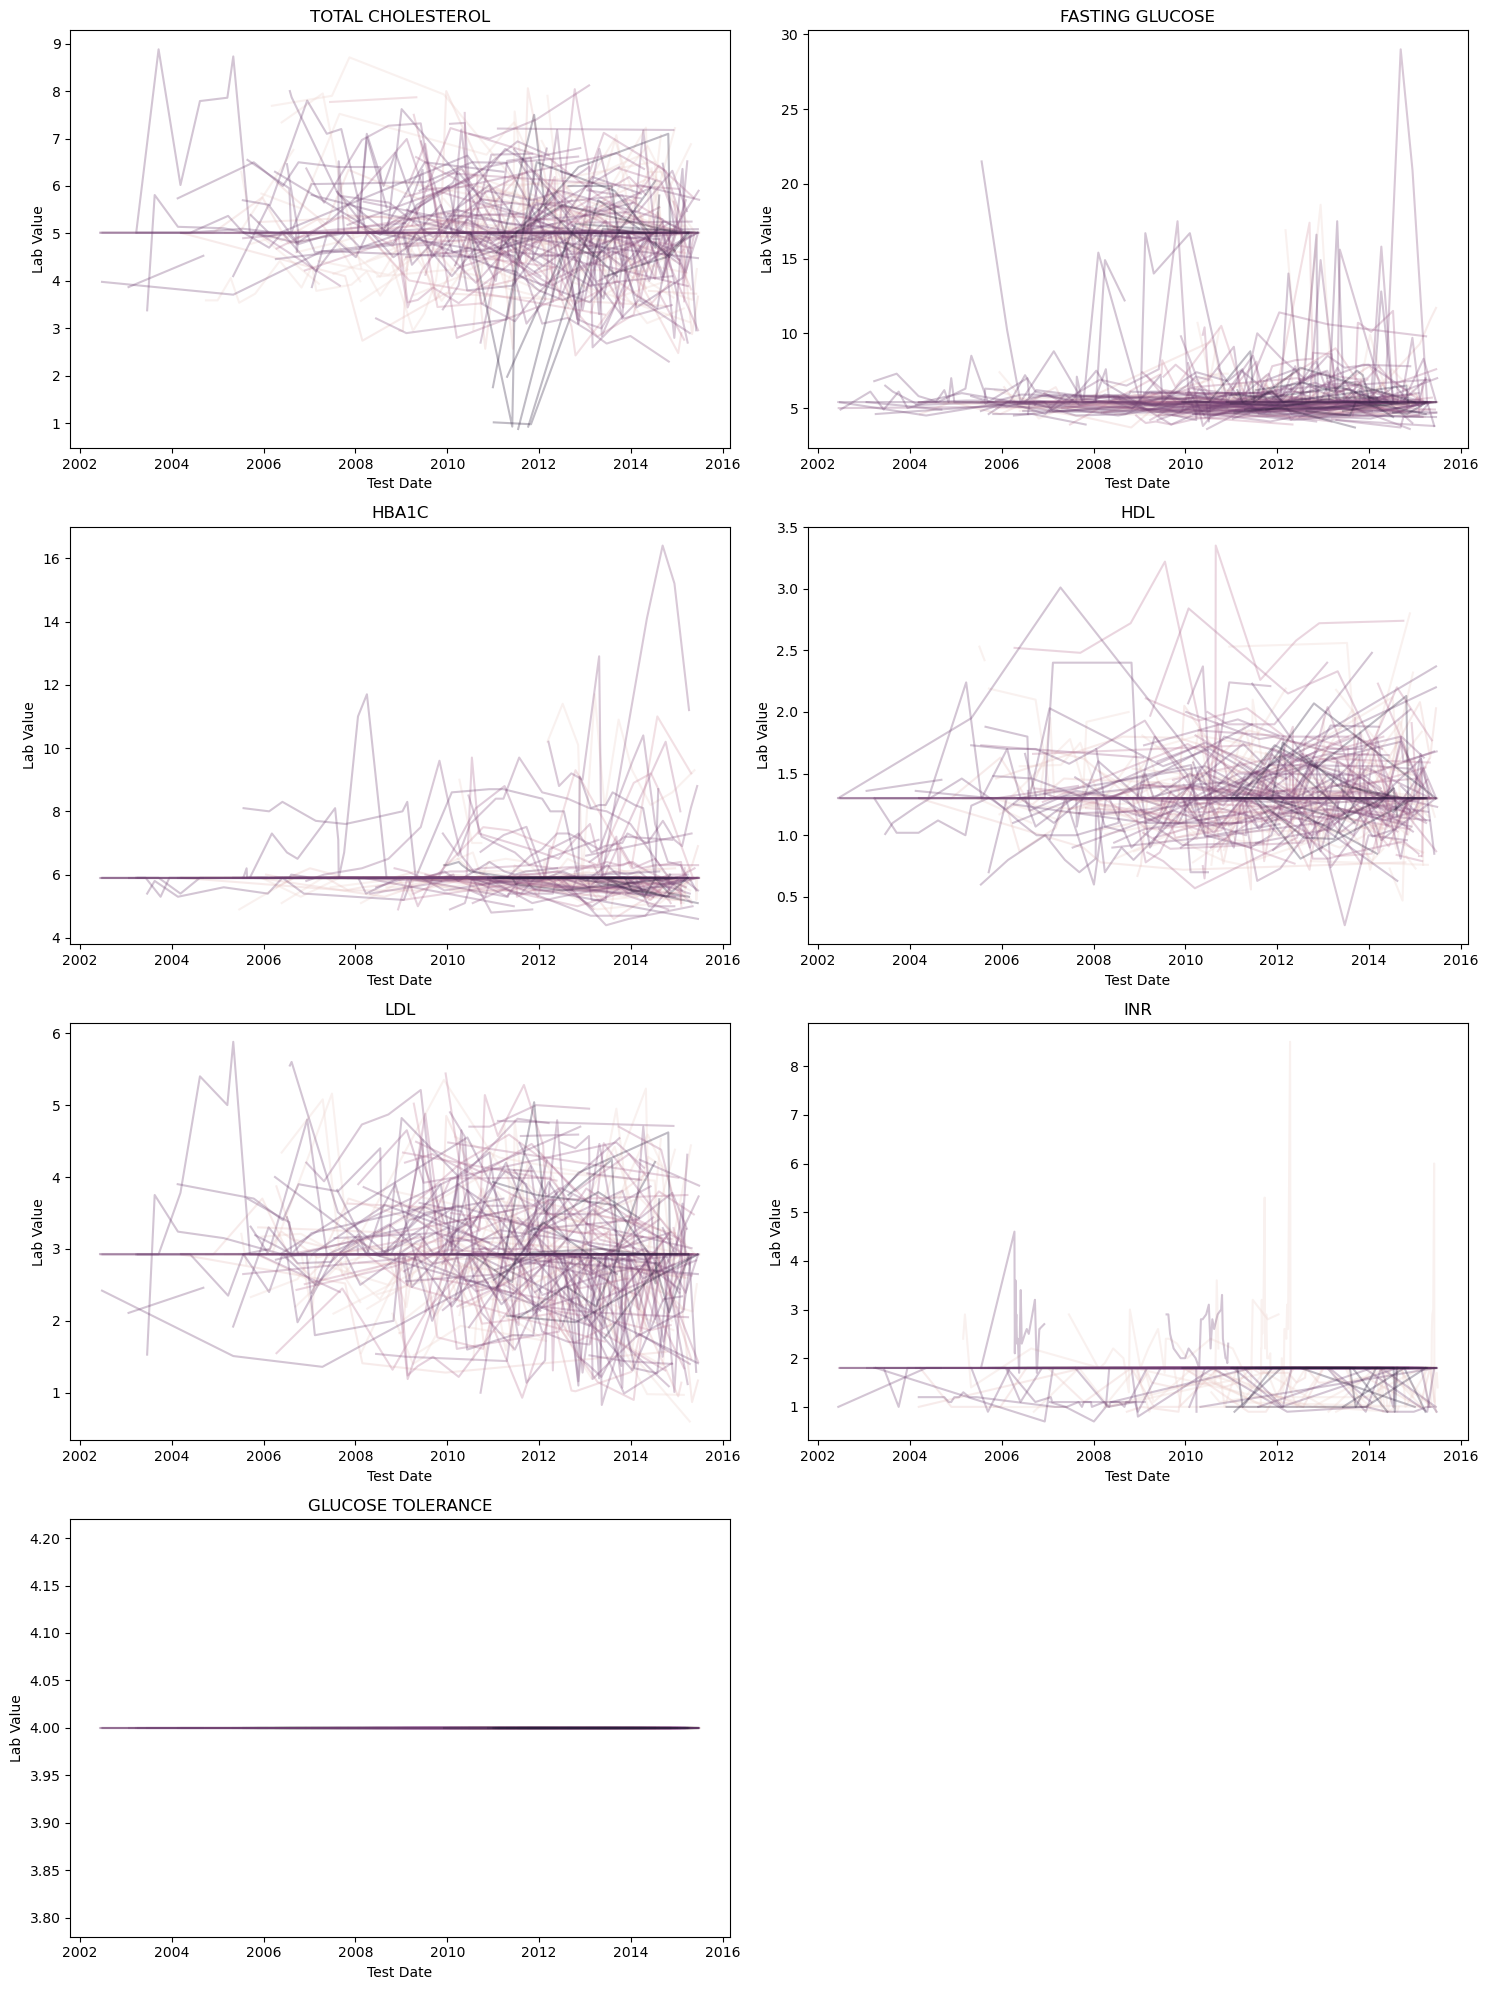

In [5]:
from functions import plot_trends
df_25 = df[df['VisitOrder'] <= 25]
plot_trends(
    data=df_25,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'],
    date='PerformedDate',
    hue='Patient_ID',
    xlabel='Test Date',
    ylabel='Lab Value'
)

## 4.3 visualize subtypes of bipolar disorder

### 4.3.1 mapping & encode subtypes of bipolar disorders

In [6]:
from functions import map_encode
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

### 4.3.2 visualize grouped trajctory of subtypes of bipolar disorders

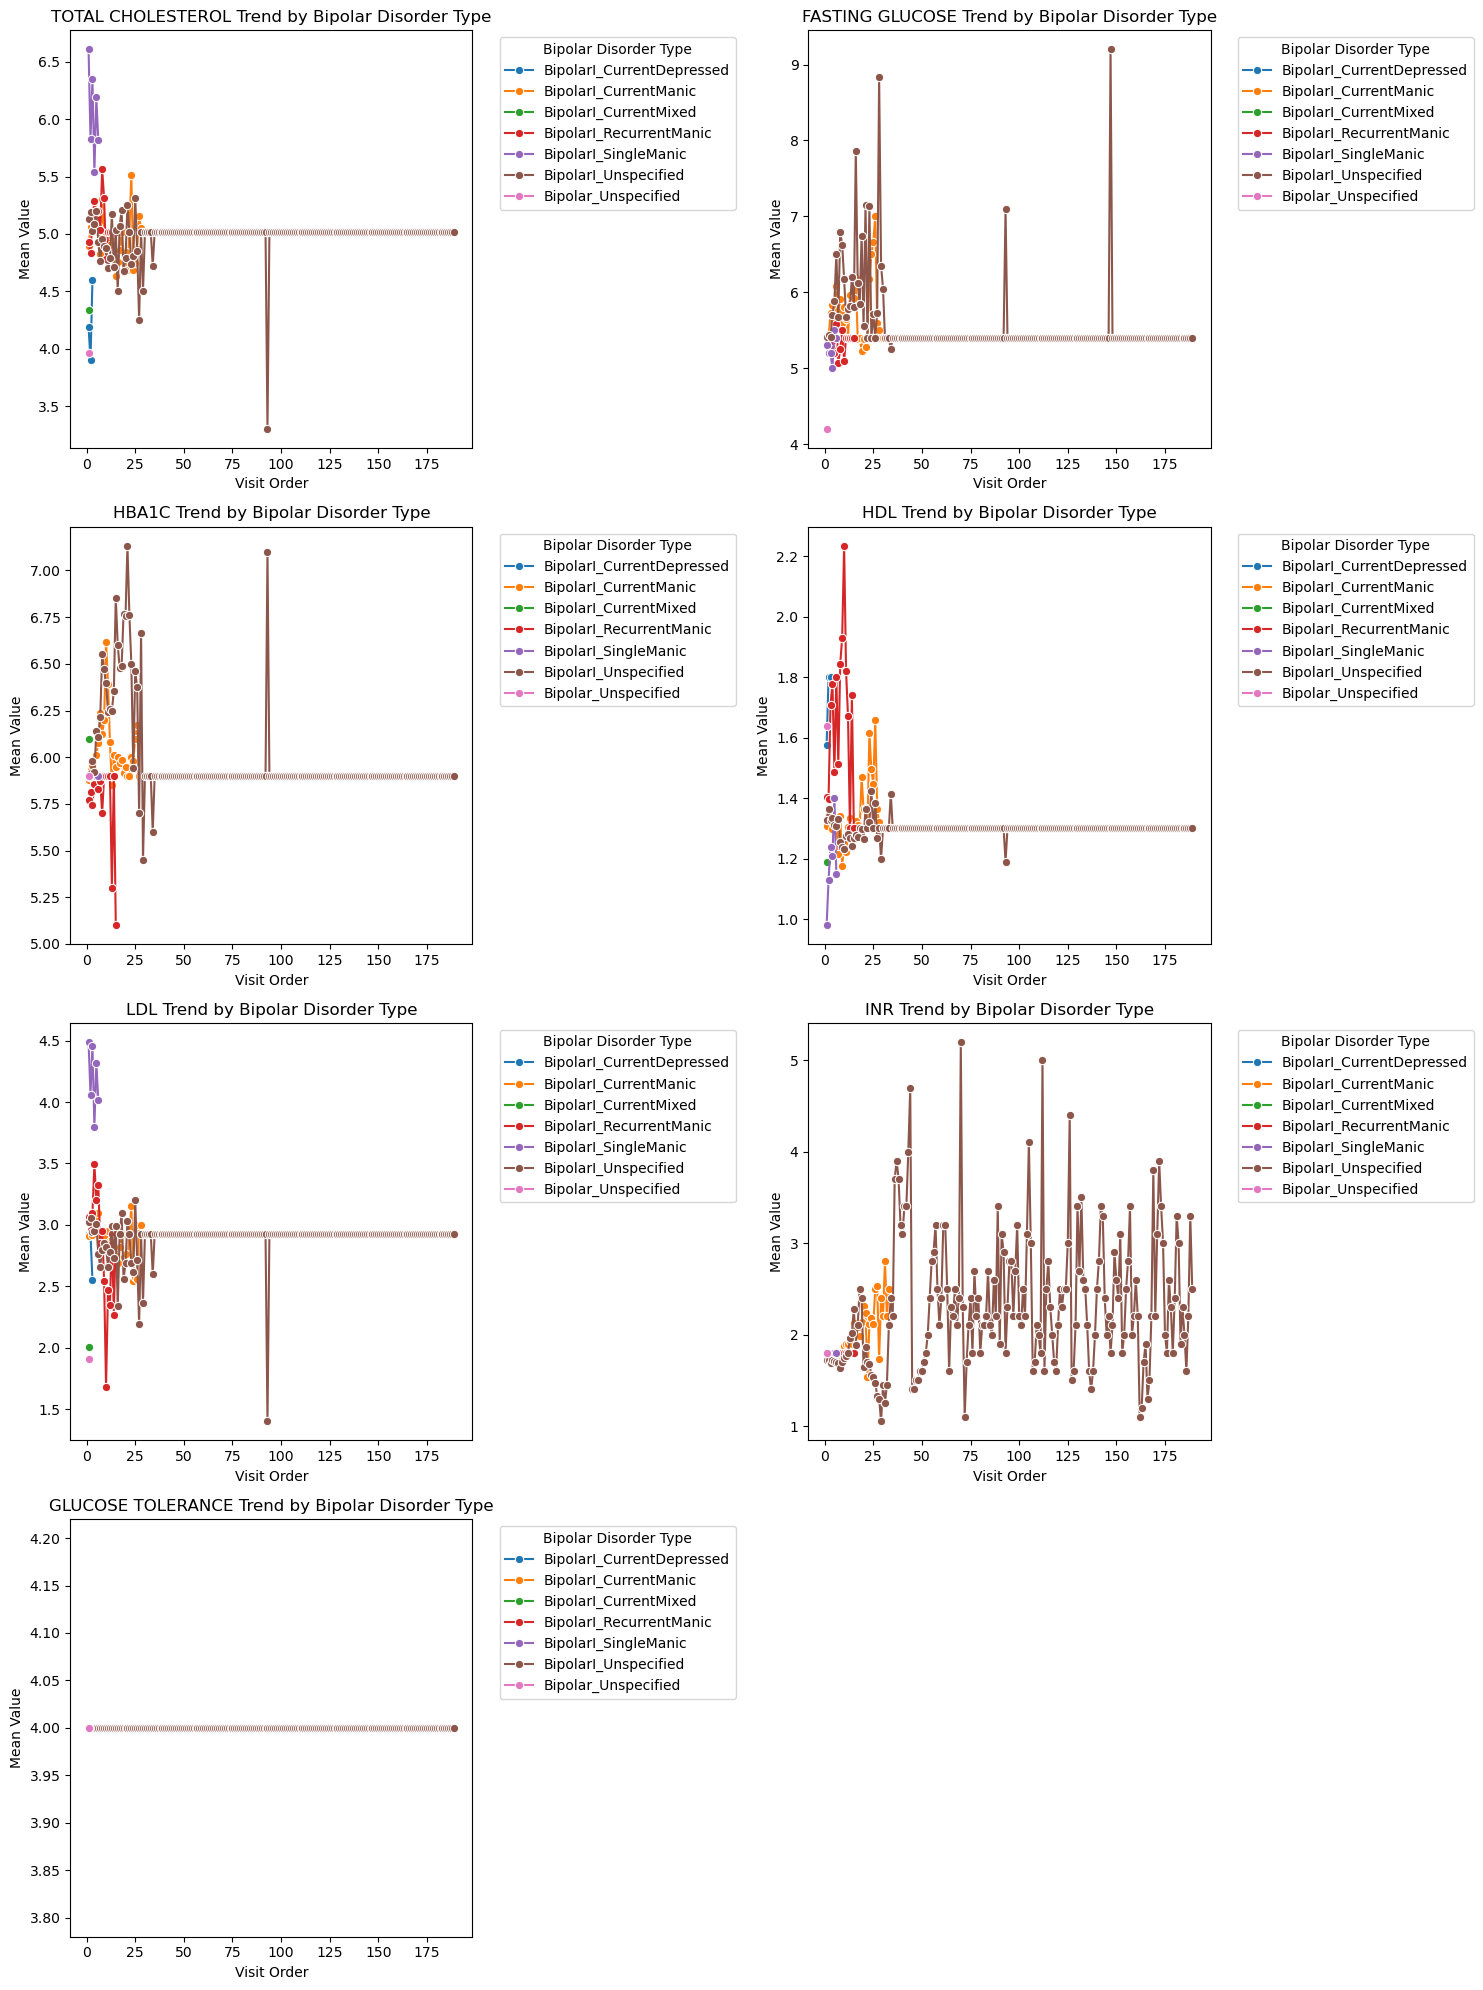

In [7]:
from functions import plot_grouped_trends

plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

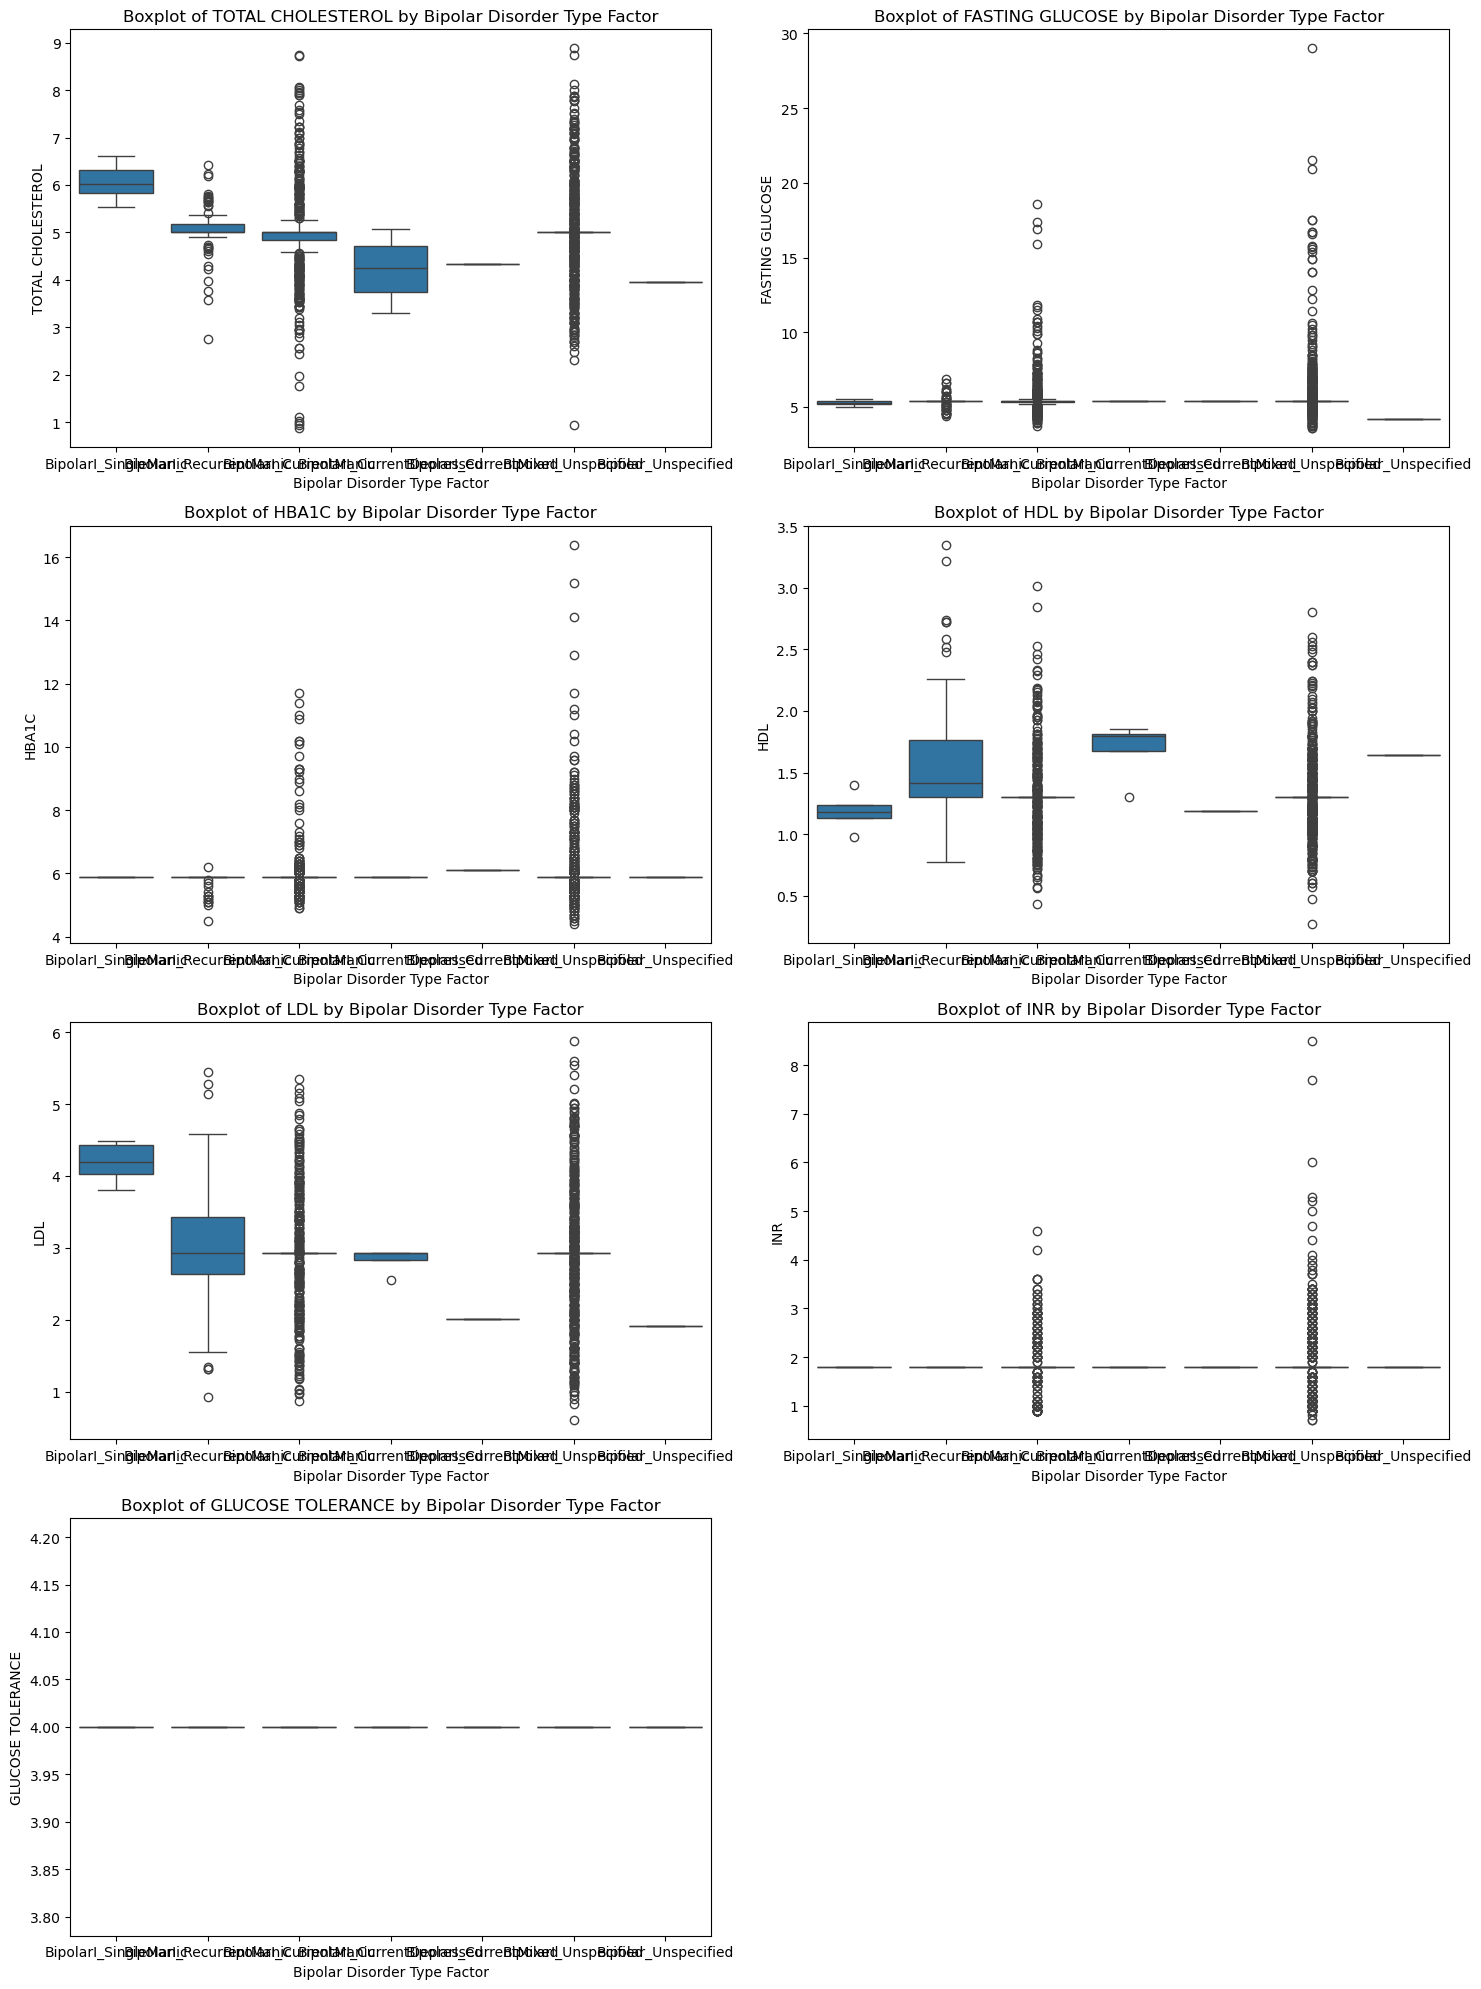

In [8]:
from functions import plot_grouped_boxplots

plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'], 
                      group='Bipolar Disorder Type Factor')

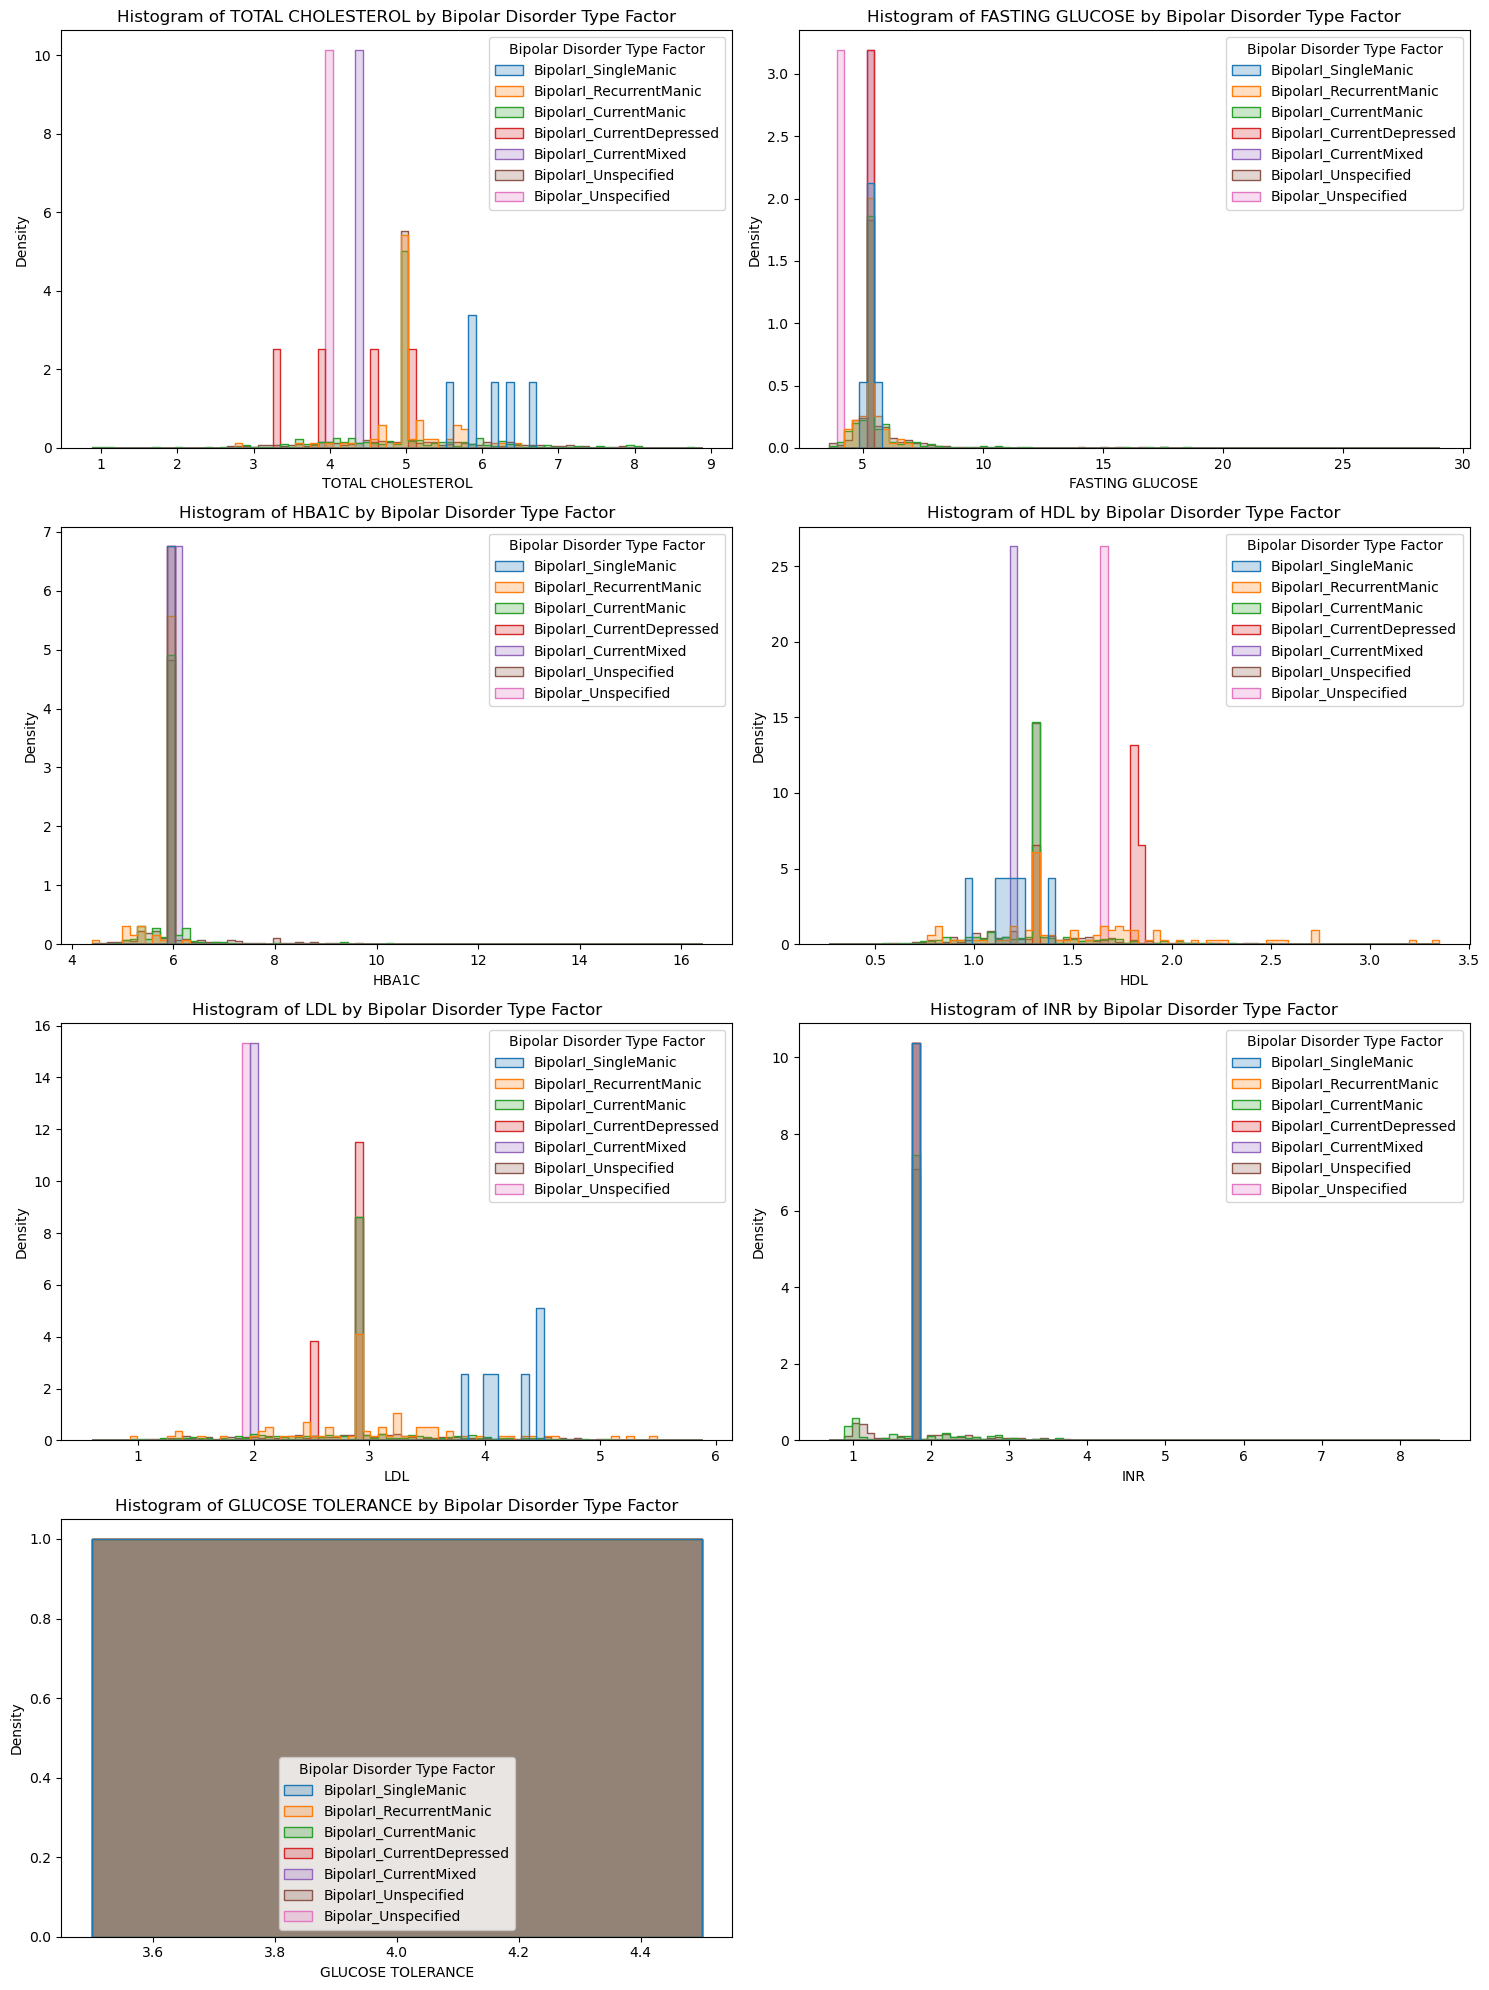

In [9]:
from functions import plot_grouped_histograms

plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'], 
                      group='Bipolar Disorder Type Factor')

In [10]:
## 4.4 visualize states of bipolar disorder

In [11]:
### 4.4.1 mapping & encode states of bipolar disorders

In [12]:
from functions import map_encode
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

<string>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<str

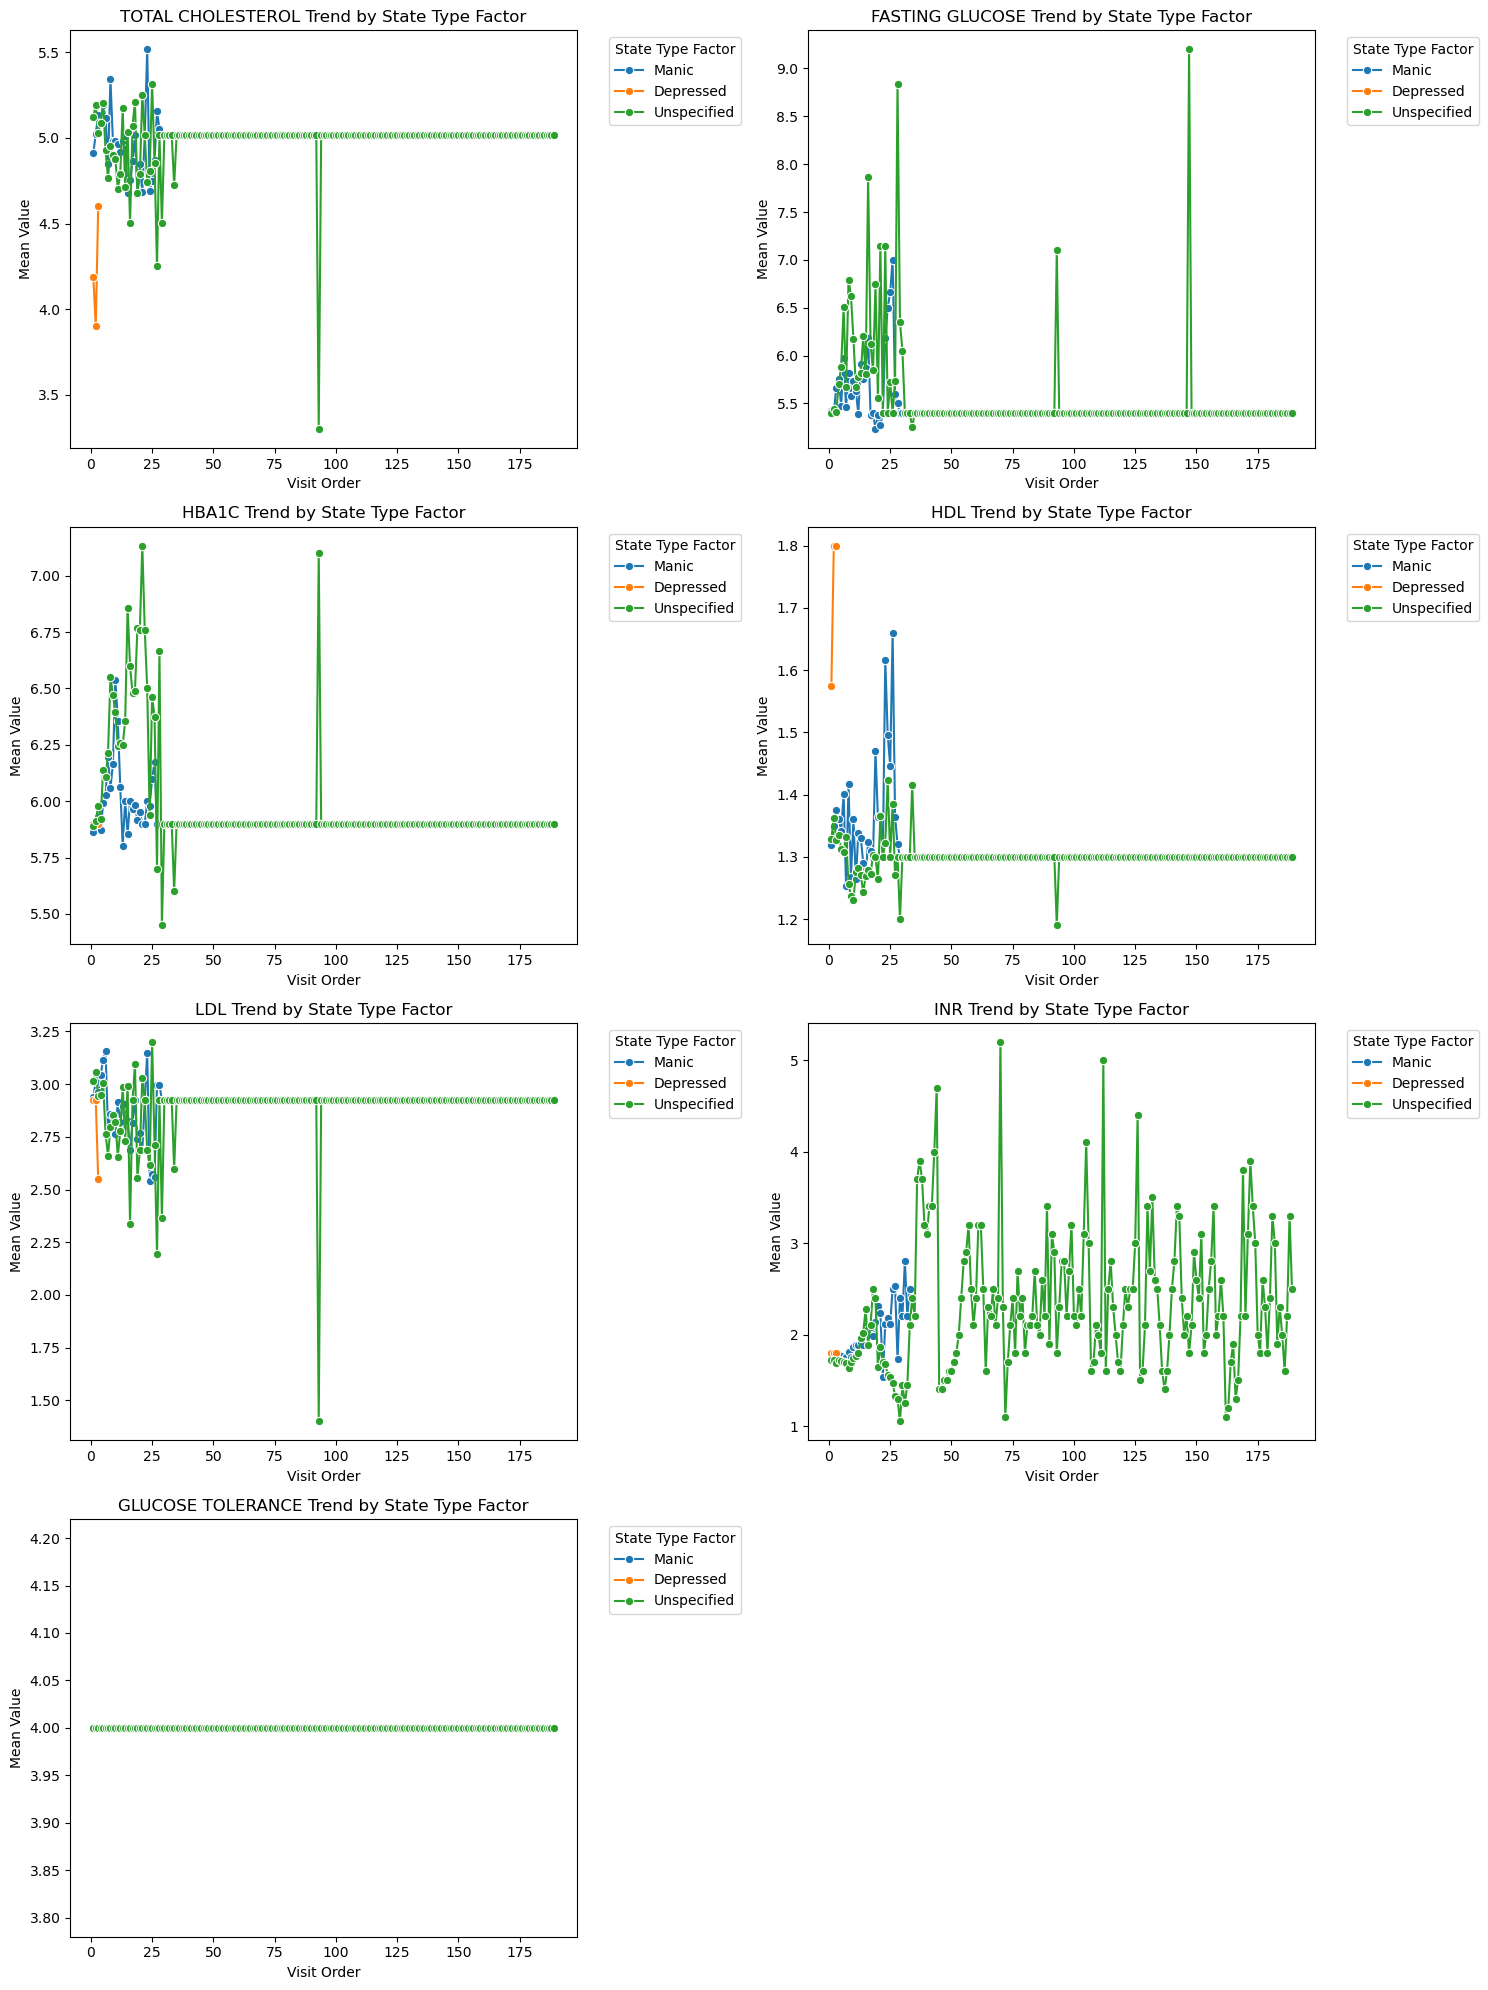

In [13]:
from functions import plot_grouped_trends

plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

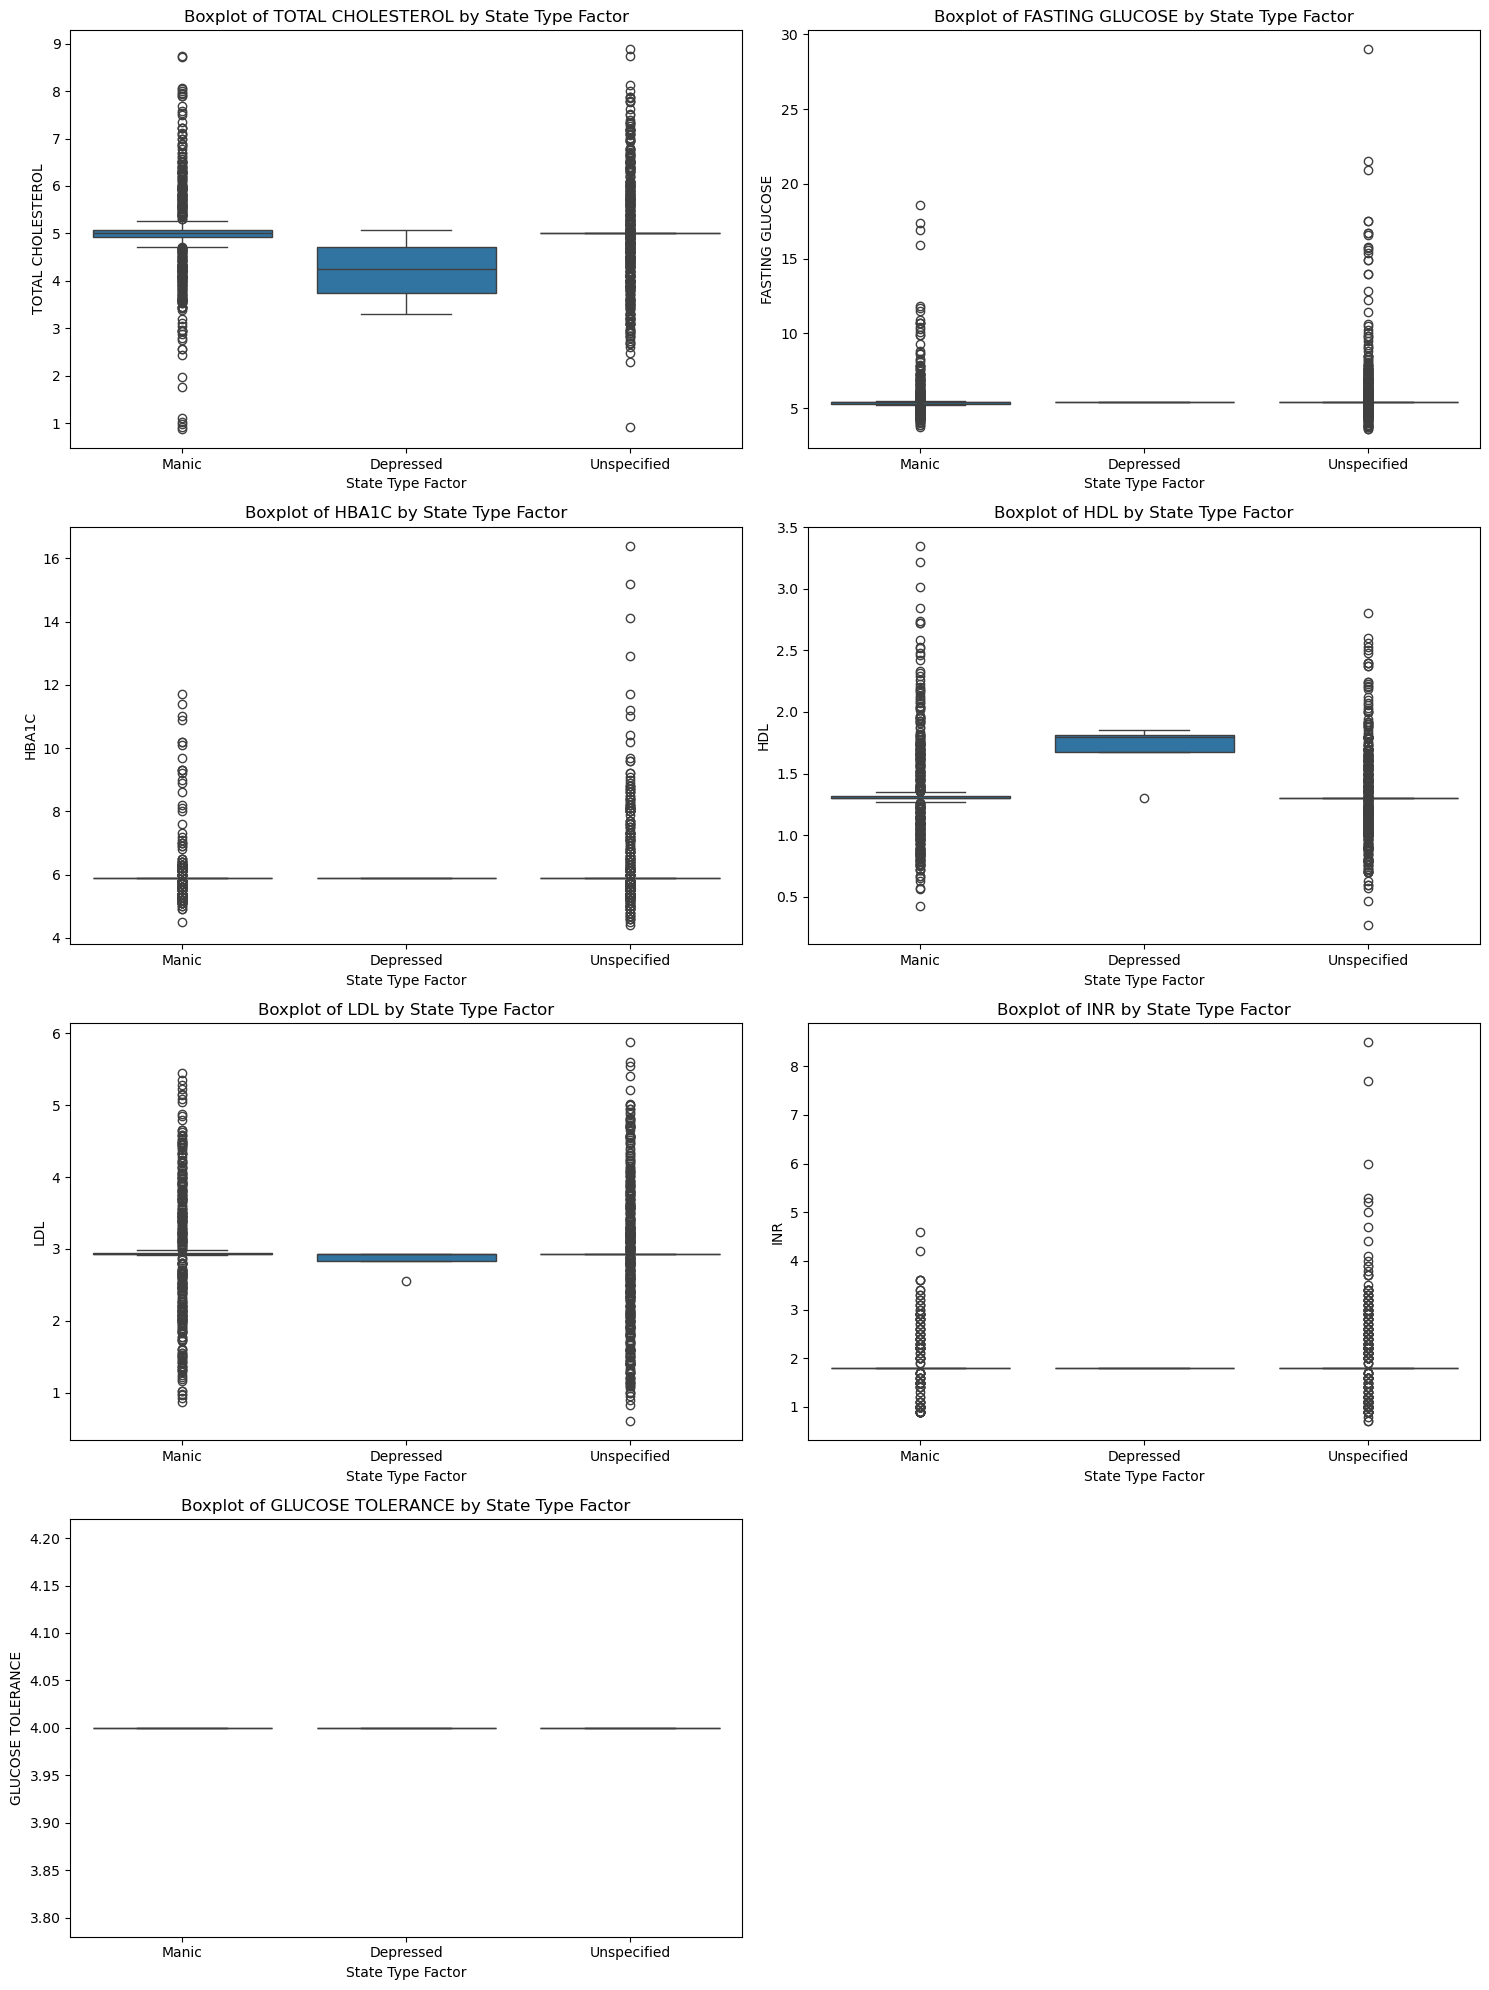

In [14]:
plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'], 
                      group='State Type Factor')

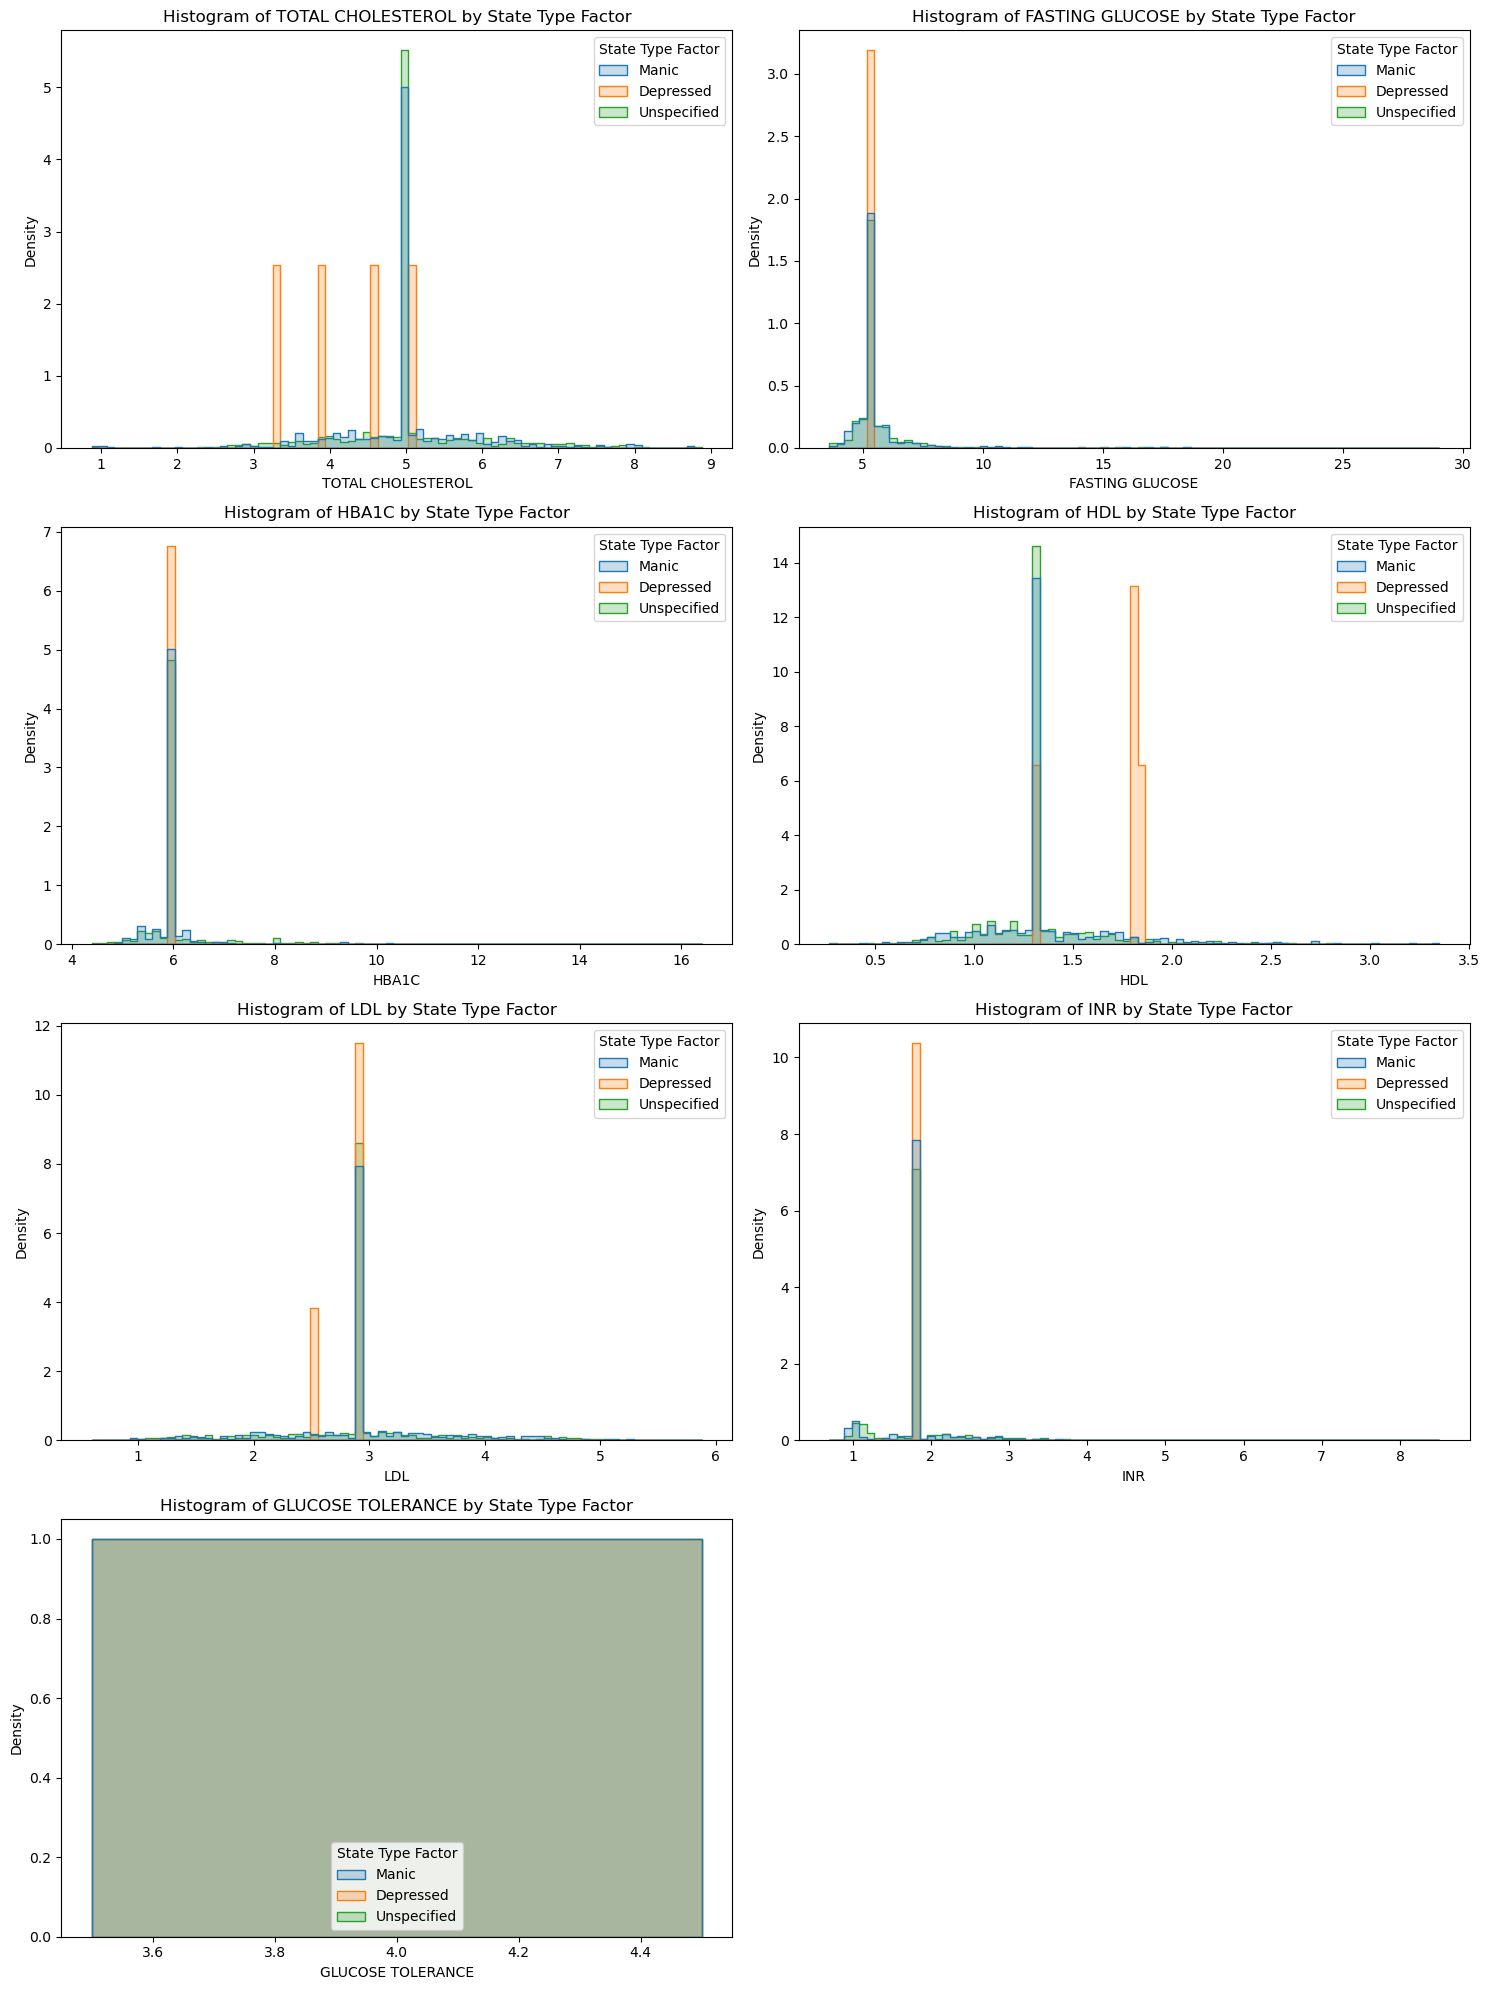

In [15]:
from functions import plot_grouped_histograms
plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'], 
                      group='State Type Factor')

# 5. Modelling

## 5.1 Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups.

In [16]:
from functions import kruskal_test
kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'], 
             group_col='Bipolar Disorder Type Factor')


TOTAL CHOLESTEROL: H=18.041, p=0.0012
FASTING GLUCOSE: H=3.992, p=0.2623
HBA1C: H=7.748, p=0.0208
HDL: H=41.204, p=0.0000
LDL: H=21.505, p=0.0003
INR: H=1.302, p=0.2539
GLUCOSE TOLERANCE: Not enough valid groups for comparison (n_groups < 2).


<string>:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,variable,n_groups,H_stat,p_value,eta_sq
0,TOTAL CHOLESTEROL,5,18.040769,1.211661e-03,None
1,FASTING GLUCOSE,4,3.992393,2.622868e-01,None
2,HBA1C,3,7.748107,2.077400e-02,None
3,HDL,5,41.204346,2.438301e-08,None
4,LDL,5,21.505389,2.513631e-04,None
5,INR,2,1.301704,2.539023e-01,None
6,GLUCOSE TOLERANCE,0,NaN,NaN,None


In [17]:
kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=3.043, p=0.2184
FASTING GLUCOSE: H=1.820, p=0.1773
HBA1C: H=1.371, p=0.2417
HDL: H=7.390, p=0.0248
LDL: H=1.751, p=0.4168
INR: H=1.194, p=0.2746
GLUCOSE TOLERANCE: Not enough valid groups for comparison (n_groups < 2).


<string>:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,variable,n_groups,H_stat,p_value,eta_sq
0,TOTAL CHOLESTEROL,3,3.043159,0.218367,None
1,FASTING GLUCOSE,2,1.820028,0.177310,None
2,HBA1C,2,1.370632,0.241703,None
3,HDL,3,7.390497,0.024841,None
4,LDL,3,1.750528,0.416752,None
5,INR,2,1.193866,0.274551,None
6,GLUCOSE TOLERANCE,0,NaN,NaN,None


In [ ]:
## 5.2 Random Forest

Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Precision (macro): 0.770

 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       188
           1       0.87      0.96      0.91       188
           2       0.71      0.66      0.69       189
           5       0.70      0.68      0.69       188

    accuracy                           0.82       753
   macro avg       0.82      0.82      0.82       753
weighted avg       0.82      0.82      0.82       753

Confusion Matrix (Raw Counts):

[[187   0   0   1]
 [  0 180   6   2]
 [  0  13 125  51]
 [  1  15  44 128]]


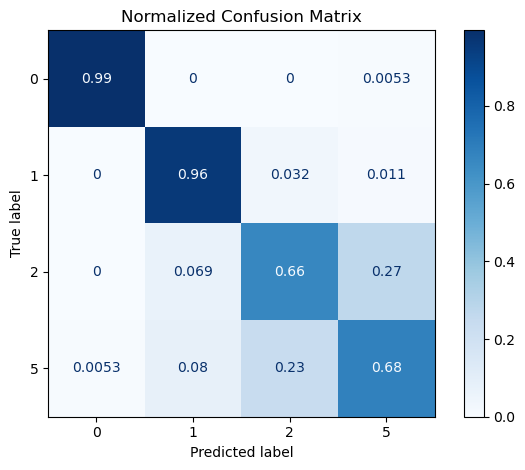

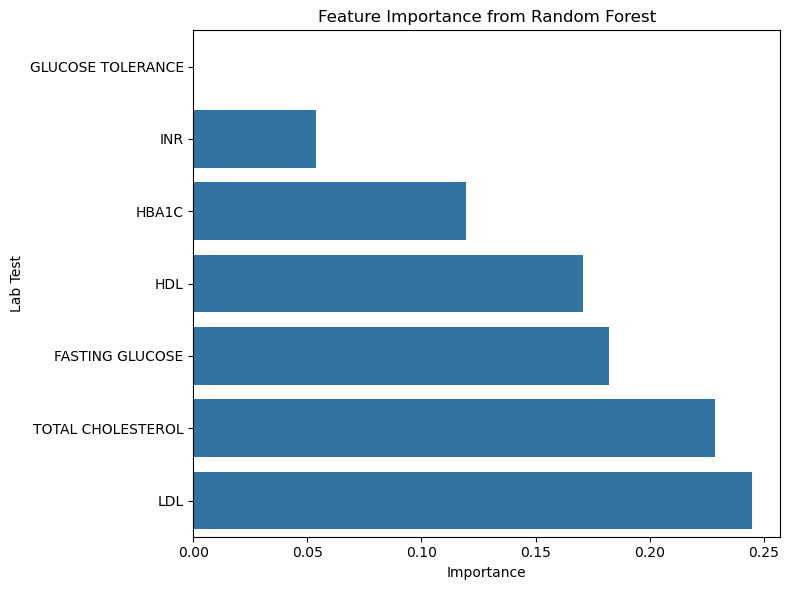


 Cross-Validated Precision (macro): 0.737 ± 0.032


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# Step 1: Data Preprocessing
# ---------------------------
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

df_clean = df.dropna(subset=lab_vars + ['Bipolar Disorder Type Factor'])

# Encode target as numeric codes
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Filter out classes with < 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

X = df_filtered[lab_vars]
y = df_filtered['Bipolar Disorder Type Factor']

# ---------------------------
# Step 2: Scale features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Step 3: Apply SMOTE
# ---------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# ---------------------------
# Step 4: Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# ---------------------------
# Step 5: Hyperparameter Tuning
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best CV Precision (macro): {grid_search.best_score_:.3f}")

# ---------------------------
# Step 6: Final Model Evaluation
# ---------------------------
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Normalized Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues", normalize='true')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 7: Feature Importance
# ---------------------------
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 8: Cross-validated Precision
# ---------------------------
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
